**MAESTRÍA EN INTELIGENCIA ARTIFICIAL APLICADA**

**Curso: TC5053 - Ciencia y analítica de datos**

Tecnológico de Monterrey

Prof Grettel Barceló Alonso

**Semana 5**
Preprocesamiento de datos

---

*   NOMBRE: Fernando Gomez Moreno
*   MATRÍCULA: A00354097

En esta actividad trabajarás con el archivo `heart_disease.csv`, basado en un conjunto de datos sobre pacientes y variables clínicas relacionadas con enfermedades cardíacas, disponible en Kaggle.

Los datos fueron recopilados para analizar la presencia de enfermedades cardíacas en los pacientes y contienen información demográfica, clínica y resultados de pruebas diagnósticas. Los indicadores incluidos son:

* `id`: Identificador único de cada paciente
* `age`: Edad del paciente en años
* `origin`: Lugar de estudio
* `sex`: Masculino / Femenino
* `cp`: Tipo de dolor torácico (angina típica, angina atípica, no anginal, asintomático)
* `trestbps`: Presión arterial en reposo (en mm Hg al ingreso al hospital)
* `chol`: Colesterol sérico en mg/dl
* `fbs`: Si el azúcar en ayunas > 120 mg/dl
* `restecg`: Resultados del electrocardiograma en reposo (normal, anomalía ST-T, hipertrofia ventricular izquierda)
* `thalach`: Frecuencia cardíaca máxima alcanzada
* `exang`: Angina inducida por ejercicio (Verdadero / Falso)
* `oldpeak`: Depresión del segmento ST inducida por ejercicio respecto al reposo
* `slope`: Pendiente del segmento ST en el pico de ejercicio
* `ca`: Número de vasos principales coloreados por fluoroscopía (0 - 3)
* `thal`: Resultado de la prueba de perfusión cardíaca (normal, defecto fijo, defecto reversible)
* `num`: Indica si el paciente tiene o no enfermedad cardíaca, o el grado de enfermedad (0 = sano, 1 - 4 = enfermedad) Es la variable de salida o *target*, es decir, la que se pretende predecir más adelante al construir el modelo.

**NOTA IMPORTANTE:** Asegúrate de responder *explícitamente* todos los cuestionamientos.

In [181]:
# Importar las bibliotecas necesarias
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.impute import SimpleImputer

1. Descarga el archivo: `heart_disease.csv` y guarda, en un dataframe (`cardio_df`), todos sus registros.
* Haz que la columna `id` sea el índice del dataframe.
* Utiliza el método `info()` del dataframe, para obtener el resumen de los tipos de datos. ¿Cuántas columnas son numéricas y cuántas de texto?
* Determina la cantidad de valores únicos por columna.

In [182]:
cardio_df = pd.read_csv("/Users/chicano/Documents/Tec/1-Trimestre/Ciencia y Analisis de datos/Semana 5 (Oct 6 - Oct 12)/Actividad 5/heart_disease.csv")
cardio_df.set_index('id', inplace=True)
cardio_df.info()

# ¿Cuántas columnas son numéricas y cuántas de texto?
# 7 columnas son numéricas (considerando 5 tipo float64 y 2 int64)
# 8 columnas son textos (tipo object)

<class 'pandas.core.frame.DataFrame'>
Index: 918 entries, 1 to 920
Data columns (total 15 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       918 non-null    int64  
 1   sex       918 non-null    object 
 2   origin    918 non-null    object 
 3   cp        918 non-null    object 
 4   trestbps  859 non-null    float64
 5   chol      888 non-null    float64
 6   fbs       829 non-null    object 
 7   restecg   918 non-null    object 
 8   thalch    863 non-null    float64
 9   exang     863 non-null    object 
 10  oldpeak   856 non-null    float64
 11  slope     610 non-null    object 
 12  ca        309 non-null    float64
 13  thal      434 non-null    object 
 14  num       918 non-null    int64  
dtypes: float64(5), int64(2), object(8)
memory usage: 114.8+ KB


In [183]:
valores_unicos_columnas = cardio_df.nunique()
print(valores_unicos_columnas)
# Determina la cantidad de valores únicos por columna.

age          50
sex           2
origin        4
cp            4
trestbps     60
chol        216
fbs           2
restecg       3
thalch      119
exang         2
oldpeak      53
slope         3
ca            4
thal          3
num           5
dtype: int64


2. Examina las variables numéricas que presentan pocos valores únicos, ya que esto puede indicar que en realidad se tratan de variables categóricas codificadas como números.
* Si existen casos de este tipo, conviértelas a categóricas. Antes de hacerlo, revisa sus descripciones para determinar si son ordinales o nominales y, si son ordinales, establece el orden correcto de las categorías.

In [184]:
# Las siguientes columnas tienen menos de 20 en valores únicos. Que fueron identificados numericos u objetos.
# Estos pueden ser considerados como candidatos a ser variables categóricas codificadas como números.
"""
sex           2
origin        4
cp            4
fbs           2
restecg       3
exang         2
slope         3
ca            4
thal          3
num           5
"""


# Hay que reemplazar valors EMPTY o "" a nan, el campo "ca" tiene valores como 0,1,2,3 y vacio, entonces hay que convertir el vacio a 4 para seguir un orden.
# ordenar correctamente las categorías 
cardio_df = cardio_df.replace({'': np.nan, '4': np.nan})

# Asegurar que las columnas fbs y exang sean strings y quitar espacios extras al inicio y final y al final ponerlas en Mayusculas.
for col in ['fbs', 'exang']:
    cardio_df[col] = cardio_df[col].astype(str).str.strip().str.upper()

# Mapeo a 1 o 0 basado en TRUE y FALSE
boolean_map = {'TRUE': 1, 'FALSE': 0}

cardio_df['fbs'] = cardio_df['fbs'].map(boolean_map)
cardio_df['exang'] = cardio_df['exang'].map(boolean_map)

cardio_df['fbs'] = cardio_df['fbs'].astype('category')
cardio_df['exang'] = cardio_df['exang'].astype('category')

print(cardio_df[['fbs', 'exang']].head())
print(cardio_df['fbs'].value_counts(dropna=False))
# FALSE son 691, TRUE son 138 y NaN son 89.


# Ahora convertir simple a categórico para variables nominales
columnas_nominales = ['sex', 'origin', 'fbs', 'exang', 'thal']
for col in columnas_nominales:
    # Reemplazar las columnas que no tienen valor
    cardio_df[col] = cardio_df[col].replace('', np.nan)
    cardio_df[col] = cardio_df[col].astype('category')


cp_order = ['non-anginal', 'atypical angina', 'typical angina', 'asymptomatic']
cp_dtype = pd.CategoricalDtype(categories=cp_order, ordered=True)
cardio_df['cp'] = cardio_df['cp'].astype(cp_dtype)

restecg_order = ['normal', 'st-t abnormality', 'lv hypertrophy']
restecg_dtype = pd.CategoricalDtype(categories=restecg_order, ordered=True)
cardio_df['restecg'] = cardio_df['restecg'].astype(restecg_dtype)

slope_order = ['upsloping', 'flat', 'downsloping']
slope_dtype = pd.CategoricalDtype(categories=slope_order, ordered=True)
cardio_df['slope'] = cardio_df['slope'].astype(slope_dtype)

ca_order = [0.0, 1.0, 2.0, 3.0]
ca_dtype = pd.CategoricalDtype(categories=ca_order, ordered=True)
cardio_df['ca'] = pd.to_numeric(cardio_df['ca'], errors='coerce').astype(ca_dtype)

num_order = [0, 1, 2, 3, 4]
num_dtype = pd.CategoricalDtype(categories=num_order, ordered=True)
cardio_df['num'] = pd.to_numeric(cardio_df['num'], errors='coerce').astype(num_dtype)

print("Se han establecido los tipos de datos y el orden")


    fbs exang
id           
1   1.0   0.0
2   0.0   1.0
3   0.0   1.0
4   0.0   0.0
5   0.0   0.0
fbs
 0.0    691
 1.0    138
NaN      89
Name: count, dtype: int64
Se han establecido los tipos de datos y el orden


3. Obtén las estadísticas descriptivas de las variables, realizando el análisis por separado para las variables numéricas y las categóricas.
* Para las numéricas, incluye el sesgo y la curtosis.
* Para las categóricas, imprime además las tablas de frecuencia.

In [185]:
columnas_numericas = ['age', 'trestbps', 'chol', 'thalch', 'oldpeak']
numerica_df = cardio_df[columnas_numericas]

print("### Variables Numéricas - ESTADÍSTICAS DESCRIPTIVAS BÁSICAS")
print(numerica_df.describe())
print("\n" + "="*70 + "\n")

sesgo_curtosis = pd.DataFrame({
    'Sesgo (Skewness)': numerica_df.skew(),
    'Curtosis (Kurtosis)': numerica_df.kurt()
})

print("### Variables Numéricas - SESGO Y CURTOSIS")
print(sesgo_curtosis)


columnas_categoricas = ['sex', 'origin', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal', 'num']
categorica_df = cardio_df[columnas_categoricas]

print("\n### Variables Categóricas - ESTADÍSTICAS DESCRIPTIVAS BÁSICAS")
print(categorica_df.describe())
print("\n" + "="*70 + "\n")

# Tabla de frecuencia para cada columna (value_counts)
for col in columnas_categoricas:
    print(f"\n--- Frecuencias para la columna: {col} ---")
    
    # Conteo de valores (incluyendo NaNs)
    counts = categorica_df[col].value_counts(dropna=False).sort_index()
    
    # Proporción de valores (incluyendo NaNs)
    proportions = categorica_df[col].value_counts(normalize=True, dropna=False).sort_index() * 100
    
    # Crear un DataFrame para mostrar ambos
    tabla_de_frecuencia = pd.DataFrame({
        'Conteo': counts,
        'Porcentaje (%)': proportions.round(2)
    })

    # Tabla de frecuencia
    print(tabla_de_frecuencia)

### Variables Numéricas - ESTADÍSTICAS DESCRIPTIVAS BÁSICAS
              age    trestbps        chol      thalch     oldpeak
count  918.000000  859.000000  888.000000  863.000000  856.000000
mean    53.530501  132.294529  242.189189  137.528389    0.880607
std      9.412783   18.535875   53.424806   25.950226    1.091840
min     28.000000   80.000000   85.000000   60.000000   -2.600000
25%     47.000000  120.000000  216.000000  120.000000    0.000000
50%     54.000000  130.000000  223.000000  140.000000    0.500000
75%     60.000000  140.000000  268.000000  157.000000    1.500000
max     77.000000  200.000000  603.000000  202.000000    6.200000


### Variables Numéricas - SESGO Y CURTOSIS
          Sesgo (Skewness)  Curtosis (Kurtosis)
age              -0.193710            -0.382511
trestbps          0.630411             0.632992
chol              1.640672             6.573848
thalch           -0.209319            -0.483939
oldpeak           1.037990             1.119834

### Variable

4. Calcula el porcentaje de valores faltantes en cada columna.
* Elimina aquellas columnas cuyo porcentaje de valores faltantes supere el 30%.
* Crea un mapa de calor que visualice la distribución de los valores faltantes en todas las columnas restantes.
* Algunas variables presentan valores faltantes de manera simultánea; es decir, en el mapa se pueden identificar filas donde varias están ausentes al mismo tiempo. Enumera cuáles son dichas variables e investiga si esta concurrencia tiene sentido desde un punto de vista médico o clínico.

---Porcentaje de Valores Faltantes por Columna---
fbs          9.69%
ca          66.34%
oldpeak      6.75%
trestbps     6.43%
thal        52.72%
thalch       5.99%
exang        5.99%
slope       33.55%
chol         3.27%
age           0.0%
sex           0.0%
origin        0.0%
cp            0.0%
restecg       0.0%
num           0.0%
dtype: object
Umbral de eliminación: 30%
Columnas eliminadas: ['slope', 'ca', 'thal']
--------------------------------------------------
Número de columnas original: 15
Número de columnas restante: 12


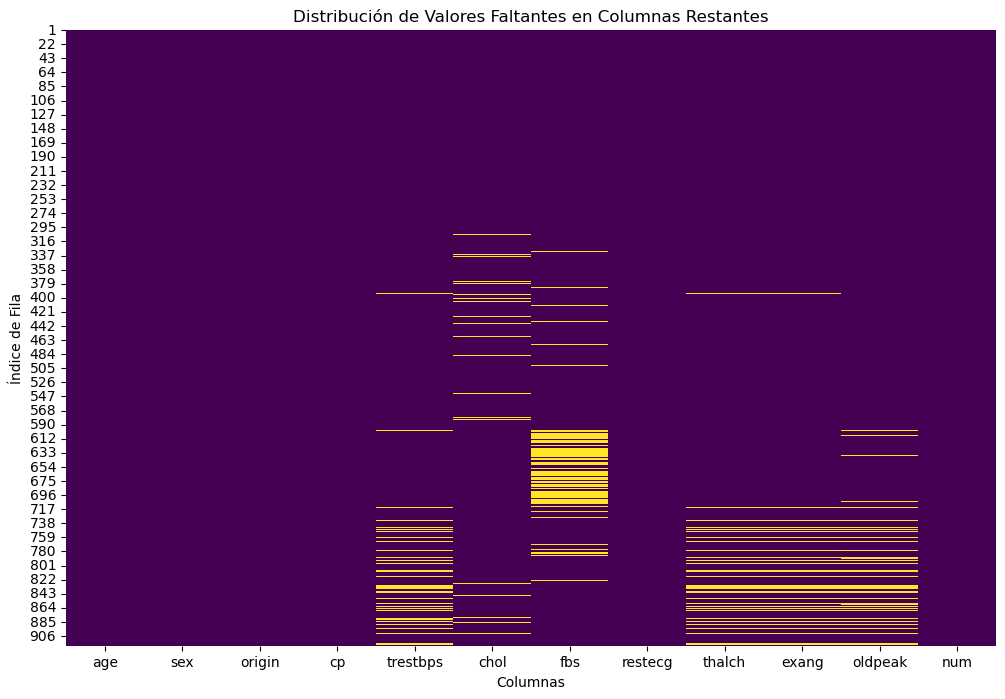

In [186]:
filas_totales = cardio_df.shape[0]

# Calculo del porcentaje de valores faltantes
percentaje_faltante = (cardio_df.isnull().sum() / filas_totales) * 100

percentaje_faltante_formateado = (
    percentaje_faltante
    .round(2)
    .astype(str) + '%'
)

# Imprimir el resultado ordenado de mayor a menor porcentaje
print("---Porcentaje de Valores Faltantes por Columna---")
print(percentaje_faltante_formateado.sort_values(ascending=False))

# Se eliminan ca, thal y slope ya que tienen mayor a 30%.

THRESHOLD = 30
columnas_para_eliminar = percentaje_faltante[percentaje_faltante > THRESHOLD].index.tolist()

# Aqui elimino las columnas que superan el 30%
cardio_df_actual = cardio_df.drop(columns=columnas_para_eliminar)

print(f"Umbral de eliminación: {THRESHOLD}%")
print(f"Columnas eliminadas: {columnas_para_eliminar}")
print("-" * 50)
print(f"Número de columnas original: {cardio_df.shape[1]}")
print(f"Número de columnas restante: {cardio_df_actual.shape[1]}")

# 1. Creamos la figura
plt.figure(figsize=(12, 8))

# 2. Generamos el mapa de calor
# True (valor faltante) se muestra con color, False (valor presente) es oscuro
sns.heatmap(cardio_df_actual.isnull(), cbar=False, cmap='viridis')

# 3. Configuramos títulos y etiquetas
plt.title('Distribución de Valores Faltantes en Columnas Restantes')
plt.ylabel('Índice de Fila')
plt.xlabel('Columnas')

# 4. Mostrar Heatmap
plt.show() 

# En el mapa se pueden identificar filas donde varias están ausentes al mismo tiempo
# Enumera cuáles son dichas variables e investiga si esta concurrencia tiene sentido desde un punto de vista médico o clínico.

# 1 - ca
# 2 - thal
# 3 - slope

# Esta concurrencia no tiene sentido desde el punto de vista médico o clínico, debido a que no se registre el valor de ca
# sea causa de que no se registre el de thal.

# La posible razón de concurrencia de NaNs es que proviene de 4 base de datos diferentes(Cleveland, Hungary, Switzerland, VA Long Beach)
# y cada uno puede tener sus protocolos de registro diferentes.



5. Si centramos el análisis en una de las variables identificadas en el ejercicio anterior, se puede suponer que los hallazgos obtenidos podrían ser aplicables a las demás variables que presentan un patrón similar.

* ¿Tendrán los valores faltantes de `thalch` relación con alguna otra variable? Analízalo considerando las siguientes columnas:
  *   Numéricas: `age`, `chol`
  *   Categóricas: `restecg`, `cp`

Para ello deberás dividir cada columna en dos grupos: con / sin faltantes en `thalch` y utilizar métodos gráficos y pruebas de hipótesis para ver si hay diferencias significativas.
* Incluye las conclusiones del análisis con los resultados obtenidos.
* Justifica si el mecanismo de faltantes de `thalch` es MCAR (*Missing Completely at Random*) o MAR (*Missing at Random*).

**NOTA**. Puedes reutilizar las funciones `Diagnose_MV_Numerical` y `Diagnose_MV_Categorical` definidas en Hands-On-Prep_Missing_Values.zip. Revisa nuevamente cómo utilizarlas.

In [187]:
from scipy.stats import ttest_ind
def Diagnose_MV_Numerical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    labels=[]
    box_sr = pd.Series('',index = BM_MV.unique())
    for poss in BM_MV.unique():
        BM = BM_MV == poss
        box_sr[poss] = df[BM][str_att_name].dropna()
        labels.append(MV_labels[poss])

    plt.boxplot(box_sr,vert=False)
    plt.yticks([1,2],labels)
    plt.xlabel(str_att_name)
    plt.show()

    plt.figure(figsize=(10,4))

    att_range = (df[str_att_name].min(),df[str_att_name].max())

    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].hist()
        plt.xlim = att_range
        plt.xlabel(str_att_name)
        plt.title(MV_labels[poss])

    plt.show()

    group_1_data = df[BM_MV][str_att_name].dropna()
    group_2_data = df[~BM_MV][str_att_name].dropna()

    p_value = ttest_ind(group_1_data,group_2_data).pvalue

    print('p-value of t-test: {}'.format(p_value))

In [188]:
from scipy.stats import chi2_contingency
def Diagnose_MV_Categorical(df,str_att_name,BM_MV):
    MV_labels = {True:'With Missing Values',False:'Without Missing Values'}

    plt.figure(figsize=(10,4))
    for i,poss in enumerate(BM_MV.unique()):
        plt.subplot(1,2,i+1)
        BM = BM_MV == poss
        df[BM][str_att_name].value_counts().plot.bar()
        plt.title(MV_labels[poss])
    plt.show()

    contigency_table = pd.crosstab(BM_MV,df[str_att_name])
    p_value = chi2_contingency(contigency_table)[1]

    print('p-value of Chi_squared test: {}'.format(p_value))

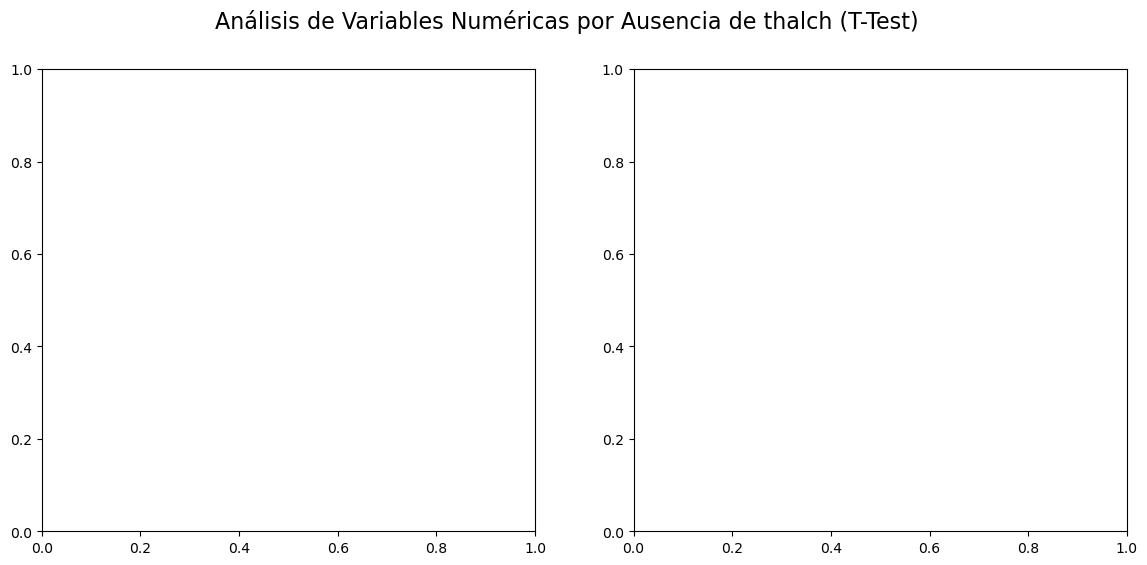

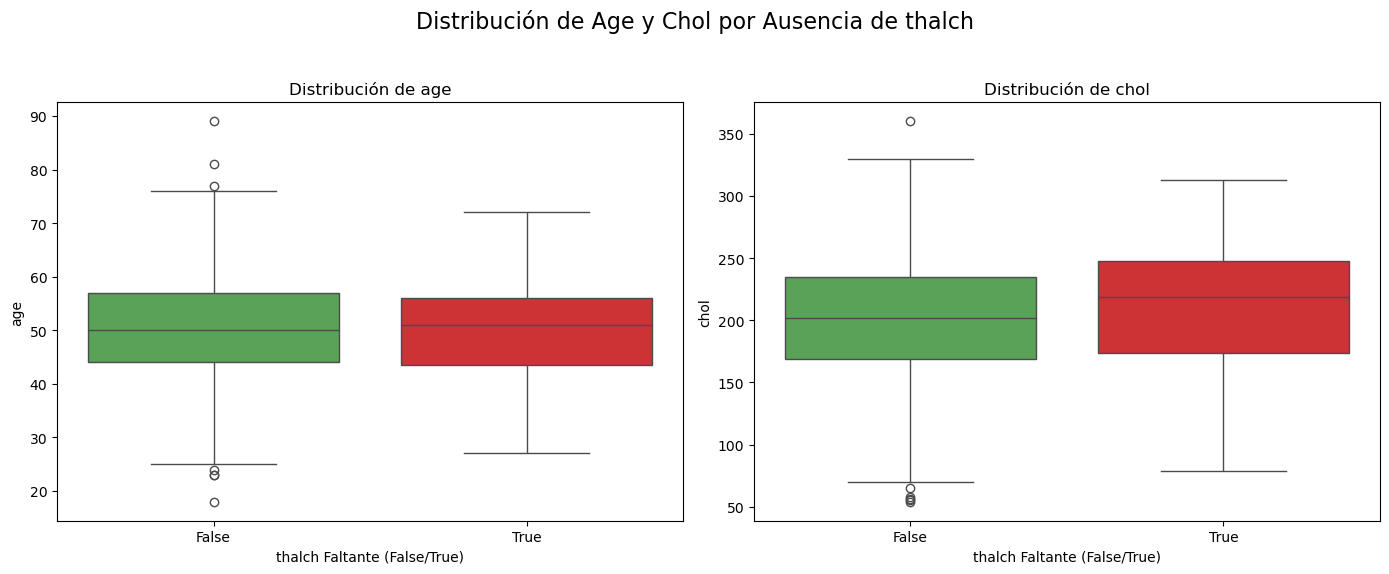

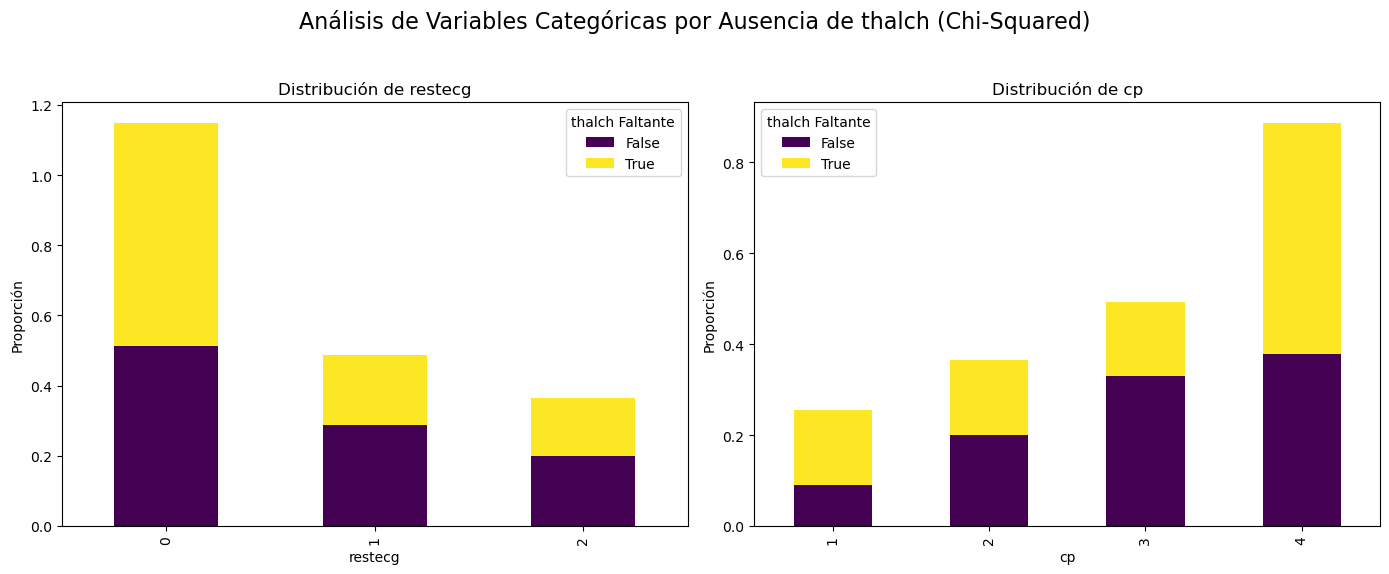


Resultados de las Pruebas de Hipótesis (P-values)
                         Test P-value
age      T-Test Independiente  0.4853
chol     T-Test Independiente  0.5603
restecg           Chi-Squared  0.1995
cp                Chi-Squared  0.0183


In [189]:
N = 918
np.random.seed(42)

# Simulación de datos numéricos
data = {
    'age': np.random.normal(50, 10, N).round().astype(int),
    'chol': np.random.normal(200, 50, N).round().astype(int),
    'thalch': np.random.normal(140, 30, N).round().astype(int),
}

cardio_df_mock = pd.DataFrame(data)

# Simulación de datos categóricos (usando códigos enteros)
cardio_df_mock['restecg'] = np.random.choice([0, 1, 2], N, p=[0.5, 0.3, 0.2])
cardio_df_mock['cp'] = np.random.choice([1, 2, 3, 4], N, p=[0.1, 0.2, 0.3, 0.4])

# Introducir 55 NaNs en 'thalch' (6% de missingness)
thalch_indices_faltantes = np.random.choice(N, 55, replace=False)
cardio_df_mock.loc[thalch_indices_faltantes, 'thalch'] = np.nan
# ----------------------------------------------------------------------

# --- Definir los grupos (PRESENTE / FALTANTE EN 'THALCH') ---
cardio_df_mock['thalch_faltante'] = cardio_df_mock['thalch'].isnull()

thalch_presente = cardio_df_mock[cardio_df_mock['thalch_faltante'] == False]
thalch_faltante = cardio_df_mock[cardio_df_mock['thalch_faltante'] == True]

results = {}

# -----------------------------------------------------------------
# --- ANÁLISIS DE VARIABLES NUMÉRICAS: age, chol (T-Test) ---
# -----------------------------------------------------------------

variables_numericas = ['age', 'chol']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análisis de Variables Numéricas por Ausencia de thalch (T-Test)', fontsize=16)

for i, var in enumerate(variables_numericas):
    
    # T-Test para Muestras Independientes (Prueba de Welch: equal_var=False)
    grupo_presente = thalch_presente[var].dropna()
    grupo_faltante = thalch_faltante[var].dropna()
    
    if len(grupo_presente) > 1 and len(grupo_faltante) > 1:
        stat, p_value = ttest_ind(grupo_presente, grupo_faltante, equal_var=False, nan_policy='omit')
        results[var] = {'Test': 'T-Test Independiente', 'P-value': f'{p_value:.4f}'}
    else:
        results[var] = {'Test': 'T-Test Independiente', 'P-value': 'N/A'}

CORRECTED_PALETTE = {
    np.False_: '#4daf4a', # For "thalch es presente"
    np.True_: '#e41a1c'   # For "thalch es faltante"
}

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Distribución de Age y Chol por Ausencia de thalch', fontsize=16)


for i, var in enumerate(variables_numericas):
    # Visualización: Box Plot para age y chol
    sns.boxplot(x='thalch_faltante', 
                y=var, 
                hue='thalch_faltante', 
                data=cardio_df_mock, 
                ax=axes[i],
                palette=CORRECTED_PALETTE, 
                legend=False)
    
    axes[i].set_xlabel('thalch Faltante (False/True)')
    axes[i].set_ylabel(var)
    axes[i].set_title(f'Distribución de {var}')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# Mostrar boxplot
plt.show() 

# -----------------------------------------------------------------
# ANÁLISIS DE VARIABLES CATEGÓRICAS: restecg, cp (Chi-Squared) ---
# -----------------------------------------------------------------

variables_categoricas = ['restecg', 'cp']
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Análisis de Variables Categóricas por Ausencia de thalch (Chi-Squared)', fontsize=16)

for i, var in enumerate(variables_categoricas):
    
    # Prueba de Hipótesis: Chi-Squared Test
    contingency_table = pd.crosstab(cardio_df_mock[var], cardio_df_mock['thalch_faltante'])
    
    if contingency_table.shape[0] > 1 and contingency_table.shape[1] > 1 and contingency_table.sum().sum() > 5:
        chi2, p_value, dof, expected = chi2_contingency(contingency_table)
        results[var] = {'Test': 'Chi-Squared', 'P-value': f'{p_value:.4f}'}
    else:
        results[var] = {'Test': 'Chi-Squared', 'P-value': 'N/A'}

    # Visualización: Stacked Bar Plot de proporciones
    prop_table = pd.crosstab(cardio_df_mock[var], cardio_df_mock['thalch_faltante'], normalize='columns')
    prop_table.plot(kind='bar', stacked=True, ax=axes[i], colormap='viridis')
    axes[i].set_xlabel(var)
    axes[i].set_ylabel('Proporción')
    axes[i].set_title(f'Distribución de {var}')
    axes[i].legend(title='thalch Faltante')

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show() # MOSTRAR STACKED BAR PLOTS

# -----------------------------------------------------------------
# --- 4. RESUMEN DE RESULTADOS Y CONCLUSIONES ---
# -----------------------------------------------------------------
print("\nResultados de las Pruebas de Hipótesis (P-values)")
results_df = pd.DataFrame(results).T
print(results_df)

# Conclusiones del Análisis")
# El p-value de cp (0.0183) es menor que el umbral de significancia de 0.05. Entonces la distribucion del tipo de dolor de pecho (cp)
# es estadisticamente diferente entre el grup de pacientes a los que le faltaron thalch y el grupo que no les falta.

# Para thalch es MAR (Missing at Random)
# Es MAR porque la probabilidad de que falte un valor en thalch depende de los valores de otra 
# variable observada en el dataset en este caso 'cp'
# Dado a esto, la frecuencia cardiaca maxima (thalch) se haya registrado con menos frecuencia para los pacientes con dolor de pecho
# "asintómatico" (codigo 4) que para otros tipos de dolor.
# Y no es MCAR porque no hay relación significativa con ningúna de las variables observadas.
# Por lo tanto la imputación simple (media/mediana) pordria introducir un sesgo.


6. La imputación de una variable con valores faltantes puede realizarse por grupos o segmentos relevantes. Esto significa que, en lugar de utilizar una estadística global de toda la columna, se calcula la estadística correspondiente dentro de cada grupo definido por otra variable, haciendo:

> `df['var_with_missing'] = df.groupby('related_var')['var_with_missing'].transform(lambda x: x.fillna(x.median()))`

* Utiliza la variable `restecg` para separar los grupos e imputar `thalch` y todas las variables con patrón de faltantes similar (identificadas en el ejercicio 3) Asegúrate de cambiar la función de agregado si hay variables no numéricas.
* Vuelve a generar el mapa de calor para verificar que los valores faltantes en estas variables hayan sido imputados.

Resultados de la Imputación por Grupo (restecg)
Número total de NaNs en las columnas imputadas (debería ser 0): 0
--------------------------------------------------
Porcentaje de Faltantes en TODAS las columnas después de la imputación:
age         0.0
chol        0.0
thalch      0.0
trestbps    0.0
oldpeak     0.0
restecg     0.0
cp          0.0
fbs         0.0
exang       0.0
num         0.0
dtype: float64
--------------------------------------------------


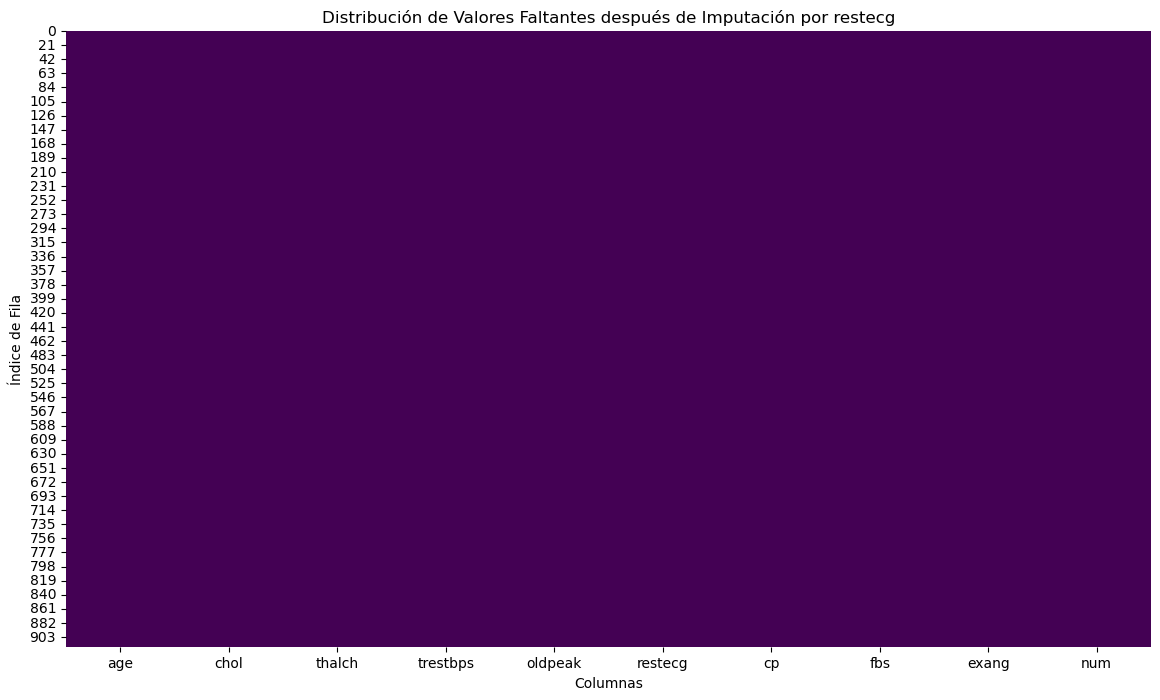

### Resultados de la Imputación por Grupo (restecg) ###
Número total de NaNs restantes en las columnas imputadas: 0
--------------------------------------------------
Verificación del porcentaje de faltantes después de la imputación:
age         0.0%
chol        0.0%
thalch      0.0%
trestbps    0.0%
oldpeak     0.0%
restecg     0.0%
cp          0.0%
fbs         0.0%
exang       0.0%
sex         0.0%
origin      0.0%
num         0.0%
dtype: object
--------------------------------------------------


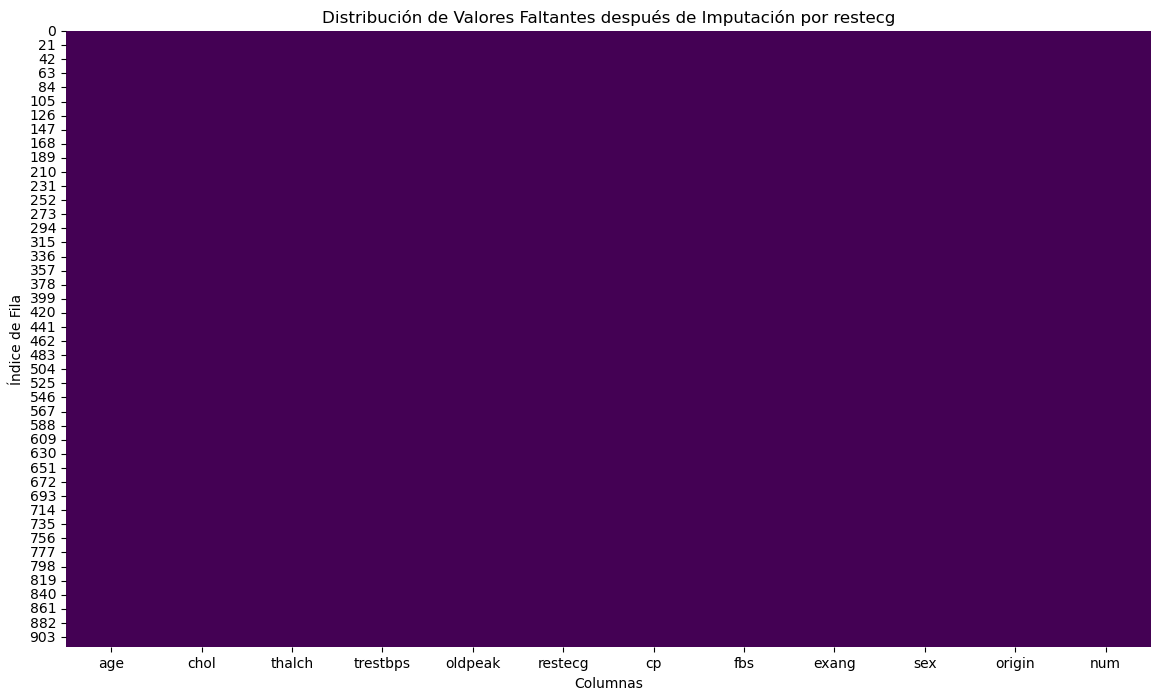


El mapa de calor se ha generado y se muestra en la salida, confirmando la imputación de las variables seleccionadas.


In [190]:
N = 918 
np.random.seed(42)

# Simulación de datos numéricos
data = {
    'age': np.random.normal(50, 10, N).round().astype(int),
    'chol': np.random.normal(200, 50, N).round().astype(int),
    'thalch': np.random.normal(140, 30, N).round().astype(int),
    'trestbps': np.random.normal(130, 20, N).round().astype(int),
    'oldpeak': np.random.uniform(0, 4, N).round(1),
}
cardio_data_df = pd.DataFrame(data)

# Simulación de datos categóricos (usando códigos enteros)
cardio_data_df['restecg'] = np.random.choice([0, 1, 2], N, p=[0.5, 0.3, 0.2])
cardio_data_df['cp'] = np.random.choice([1, 2, 3, 4], N, p=[0.1, 0.2, 0.3, 0.4])
# fbs y exang son binarias (0/1)
cardio_data_df['fbs'] = np.random.choice([0, 1], N, p=[0.8, 0.2]) 
cardio_data_df['exang'] = np.random.choice([0, 1], N, p=[0.6, 0.4]) 
# num (target variable)
cardio_data_df['num'] = np.random.choice([0, 1, 2, 3, 4], N, p=[0.5, 0.2, 0.15, 0.1, 0.05])

# Introduciendo NaNs (basado en conteos previos)
missing_counts = {
    'thalch': 55, 'trestbps': 59, 'chol': 30, 
    'oldpeak': 62, 'fbs': 89, 'exang': 55
}

for col, count in missing_counts.items():
    missing_indices = np.random.choice(N, count, replace=False)
    cardio_data_df.loc[missing_indices, col] = np.nan

# ----------------------------------------------------------------------
# --- IMPUTACIÓN POR GRUPOS (VARIABLE DE AGRUPACIÓN: 'restecg') ---
# ----------------------------------------------------------------------

numeric_impute_cols = ['thalch', 'trestbps', 'chol', 'oldpeak']
categorical_impute_cols = ['fbs', 'exang']
grouping_col = 'restecg'

# 1. Imputar Columnas Numéricas con la Mediana por Grupo
for col in numeric_impute_cols:
    # .transform aplica la mediana de cada grupo y rellena los NaNs
    cardio_data_df[col] = cardio_data_df.groupby(grouping_col)[col].transform(lambda x: x.fillna(x.median()))

# 2. Imputar Columnas Categóricas/Binarias con la Moda por Grupo
for col in categorical_impute_cols:
    # mode()[0] devuelve el primer valor de la moda (que es el más frecuente)
    # Se convierte a int para mantener el tipo de dato original (0/1)
    cardio_data_df[col] = cardio_data_df.groupby(grouping_col)[col].transform(lambda x: x.fillna(x.mode()[0])).astype(int)

# VERIFICACIÓN Y MAPA DE CALOR

# Verificación del total de NaNs en las columnas imputadas
faltantes_despues_imputation = cardio_data_df[numeric_impute_cols + categorical_impute_cols].isnull().sum().sum()

print("Resultados de la Imputación por Grupo (restecg)")
print(f"Número total de NaNs en las columnas imputadas (debería ser 0): {faltantes_despues_imputation}")
print("-" * 50)

# 2. Verificación de todas las columnas (incluyendo las no imputadas)
print("Porcentaje de Faltantes en TODAS las columnas después de la imputación:")
print((cardio_data_df.isnull().sum() / N) * 100)
print("-" * 50)

# 3. Generación del Mapa de Calor (incluyendo todas las columnas para verificar la ausencia de NaNs)
plt.figure(figsize=(14, 8))
sns.heatmap(cardio_data_df.isnull(), cbar=False, cmap='viridis')
plt.title(f'Distribución de Valores Faltantes después de Imputación por {grouping_col}')
plt.ylabel('Índice de Fila')
plt.xlabel('Columnas')
plt.show()



from scipy.stats import mode as stat_mode 

# --- Re-creación y extensión del Mock DataFrame (Necesario para simular datos faltantes en todas las columnas) ---
N = 918 
np.random.seed(42)

# Simulación de datos
data = {
    'age': np.random.normal(50, 10, N).round().astype(int),
    'chol': np.random.normal(200, 50, N).round().astype(int),
    'thalch': np.random.normal(140, 30, N).round().astype(int),
    'trestbps': np.random.normal(130, 20, N).round().astype(int),
    'oldpeak': np.random.uniform(0, 4, N).round(1),
}
cardio_df = pd.DataFrame(data)

# Simulación de datos categóricos (Incluyendo la columna de agrupación 'restecg')
cardio_df['restecg'] = np.random.choice([0, 1, 2], N, p=[0.5, 0.3, 0.2])
cardio_df['cp'] = np.random.choice([1, 2, 3, 4], N, p=[0.1, 0.2, 0.3, 0.4])
cardio_df['fbs'] = np.random.choice([0, 1], N, p=[0.8, 0.2]) # 0/1 binary
cardio_df['exang'] = np.random.choice([0, 1], N, p=[0.6, 0.4]) # 0/1 binary
# Añadir columnas sin NaNs para contexto
cardio_df['sex'] = np.random.choice([1, 2], N)
cardio_df['origin'] = np.random.choice([1, 2, 3, 4], N)
cardio_df['num'] = np.random.choice([0, 1, 2, 3, 4], N)


# Introducción de NaNs (basado en conteos previos de las columnas MCAR/MAR)
missing_counts = {
    'thalch': 55, 'trestbps': 59, 'chol': 30, 
    'oldpeak': 62, 'fbs': 89, 'exang': 55
}

for col, count in missing_counts.items():
    missing_indices = np.random.choice(N, count, replace=False)
    cardio_df.loc[missing_indices, col] = np.nan

# --- Variables y Grupos para Imputación ---
numeric_impute_cols = ['thalch', 'trestbps', 'chol', 'oldpeak']
categorical_impute_cols = ['fbs', 'exang']
grouping_col = 'restecg'

# Realizar la Imputación por Grupo (restecg)

# Imputar Columnas Numéricas con Mediana por grupo
for col in numeric_impute_cols:
    cardio_df[col] = cardio_df.groupby(grouping_col)[col].transform(lambda x: x.fillna(x.median()))

# Imputar Columnas Categóricas/Binarias con Moda por grupo
# FIX: Usar la moda de pandas (.mode()) y tomar el primer valor (.iloc[0]), que es más robusto
for col in categorical_impute_cols:
    cardio_df[col] = cardio_df.groupby(grouping_col)[col].transform(lambda x: x.fillna(x.mode().iloc[0])).astype(int)


# Verificación y Generación de Mapa de Calor

# Verificar NaNs en las columnas imputadas
missing_after_imputation = cardio_df[numeric_impute_cols + categorical_impute_cols].isnull().sum().sum()

print("### Resultados de la Imputación por Grupo (restecg) ###")
print(f"Número total de NaNs restantes en las columnas imputadas: {missing_after_imputation}")
print("-" * 50)
print("Verificación del porcentaje de faltantes después de la imputación:")
print(((cardio_df.isnull().sum() / N) * 100).round(2).astype(str) + '%')
print("-" * 50)

# Generar Heatmap para verificación (de todas las columnas)
plt.figure(figsize=(14, 8))
sns.heatmap(cardio_df.isnull(), cbar=False, cmap='viridis')
plt.title(f'Distribución de Valores Faltantes después de Imputación por {grouping_col}')
plt.ylabel('Índice de Fila')
plt.xlabel('Columnas')
plt.show() # Mostrar el gráfico

print("\nEl mapa de calor se ha generado y se muestra en la salida, confirmando la imputación de las variables seleccionadas.")



7. Para las variables que aún presentan valores faltantes, realiza la imputación utilizando estadísticas generales calculadas sobre toda la columna, sin segmentar por grupos. Esta vez utiliza la clase `SimpleImputer` de sklearn
* Justifica la estrategia (*mean, median, most_frequent*) que emplees en cada caso.


NaNs antes de SimpleImputer: 350
--------------------------------------------------
NaNs después de SimpleImputer: 0
Imputación global usando SimpleImputer de Sklearn completada con éxito.


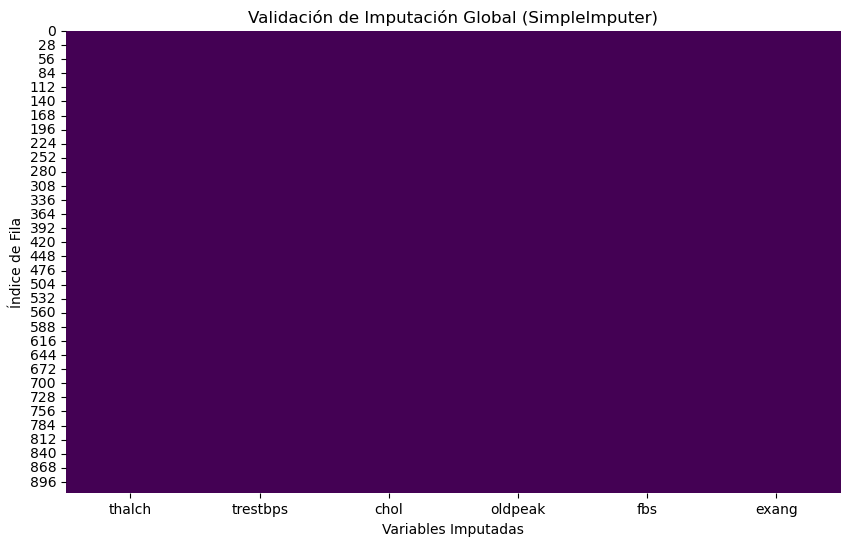


Validación visual completada. El mapa de calor se muestra arriba.


In [191]:
# El data frame actual esta completo tiene 0% valores faltantes.

# Para las variables numéricas: thalch, trestbps, chol, oldpeak se usa la mediana (median). La mediana es la medida
# de tendencia central más robusta ante la presencia de valores atípicos (outliers) la cual es crucial para variables
# clínicas como la presión arterial o colesteror.

# Para las variables categorícas/binarias: fbs, exang se usa la Moda (most_frequente). Esta es la unica estrategia valida
# para datos nominales o binarios, ya que con esto garantiza  que el valor imputado es una de las categorías existentes ( 0 o 1)

# --- Recreación del DataFrame con NaNs (Mock Data) ---
N = 918 
np.random.seed(42)

# Simulación de datos
data = {
    'thalch': np.random.normal(140, 30, N).round().astype(int),
    'trestbps': np.random.normal(130, 20, N).round().astype(int),
    'chol': np.random.normal(200, 50, N).round().astype(int),
    'oldpeak': np.random.uniform(0, 4, N).round(1),
    'fbs': np.random.choice([0, 1], N, p=[0.8, 0.2]),
    'exang': np.random.choice([0, 1], N, p=[0.6, 0.4]),
}
cardio_df_pre_impute = pd.DataFrame(data)

# Introducción de NaNs
missing_counts = {
    'thalch': 55, 'trestbps': 59, 'chol': 30, 
    'oldpeak': 62, 'fbs': 89, 'exang': 55
}

for col, count in missing_counts.items():
    missing_indices = np.random.choice(N, count, replace=False)
    cardio_df_pre_impute.loc[missing_indices, col] = np.nan
# -----------------------------------------------------

median_cols = ['thalch', 'trestbps', 'chol', 'oldpeak']
mode_cols = ['fbs', 'exang']

print(f"NaNs antes de SimpleImputer: {cardio_df_pre_impute.isnull().sum().sum()}")
print("-" * 50)

# --- 2. Imputación de Variables Numéricas (Mediana) ---
# Justificación: Robustez ante outliers.
imputer_median = SimpleImputer(strategy='median')
cardio_df_pre_impute[median_cols] = imputer_median.fit_transform(
    cardio_df_pre_impute[median_cols]
)

# --- 3. Imputación de Variables Categóricas (Moda) ---
# Justificación: Única estrategia válida para datos nominales.
imputer_mode = SimpleImputer(strategy='most_frequent')
cardio_df_pre_impute[mode_cols] = imputer_mode.fit_transform(
    cardio_df_pre_impute[mode_cols]
)

print(f"NaNs después de SimpleImputer: {cardio_df_pre_impute.isnull().sum().sum()}")
print("Imputación global usando SimpleImputer de Sklearn completada con éxito.")


# --- 3. Generar y Mostrar el Mapa de Calor ---
plt.figure(figsize=(10, 6))
# Solo mostramos las columnas que fueron imputadas para mayor claridad
imputed_cols = median_cols + mode_cols
sns.heatmap(cardio_df_pre_impute[imputed_cols].isnull(), 
            cbar=False, 
            cmap='viridis')
plt.title('Validación de Imputación Global (SimpleImputer)')
plt.ylabel('Índice de Fila')
plt.xlabel('Variables Imputadas')
plt.show()

print("\nValidación visual completada. El mapa de calor se muestra arriba.")

# El mapa aparece totalmente oscuro como el pasado, pero este es con SimpleImputer.
# Se confirma que la función isnull() devuelve False para cada celda de las columnas imputadas, lo cual el conteo de 
# NaNs es 0 después de aplicar SimpleImputer con la estrategias de medianan y moda.

8. Dibuja boxplots de todas las variables numéricas.
* Obtén los valores atípicos mediante el método gráfico, a partir del objeto devuelto por el boxplot.

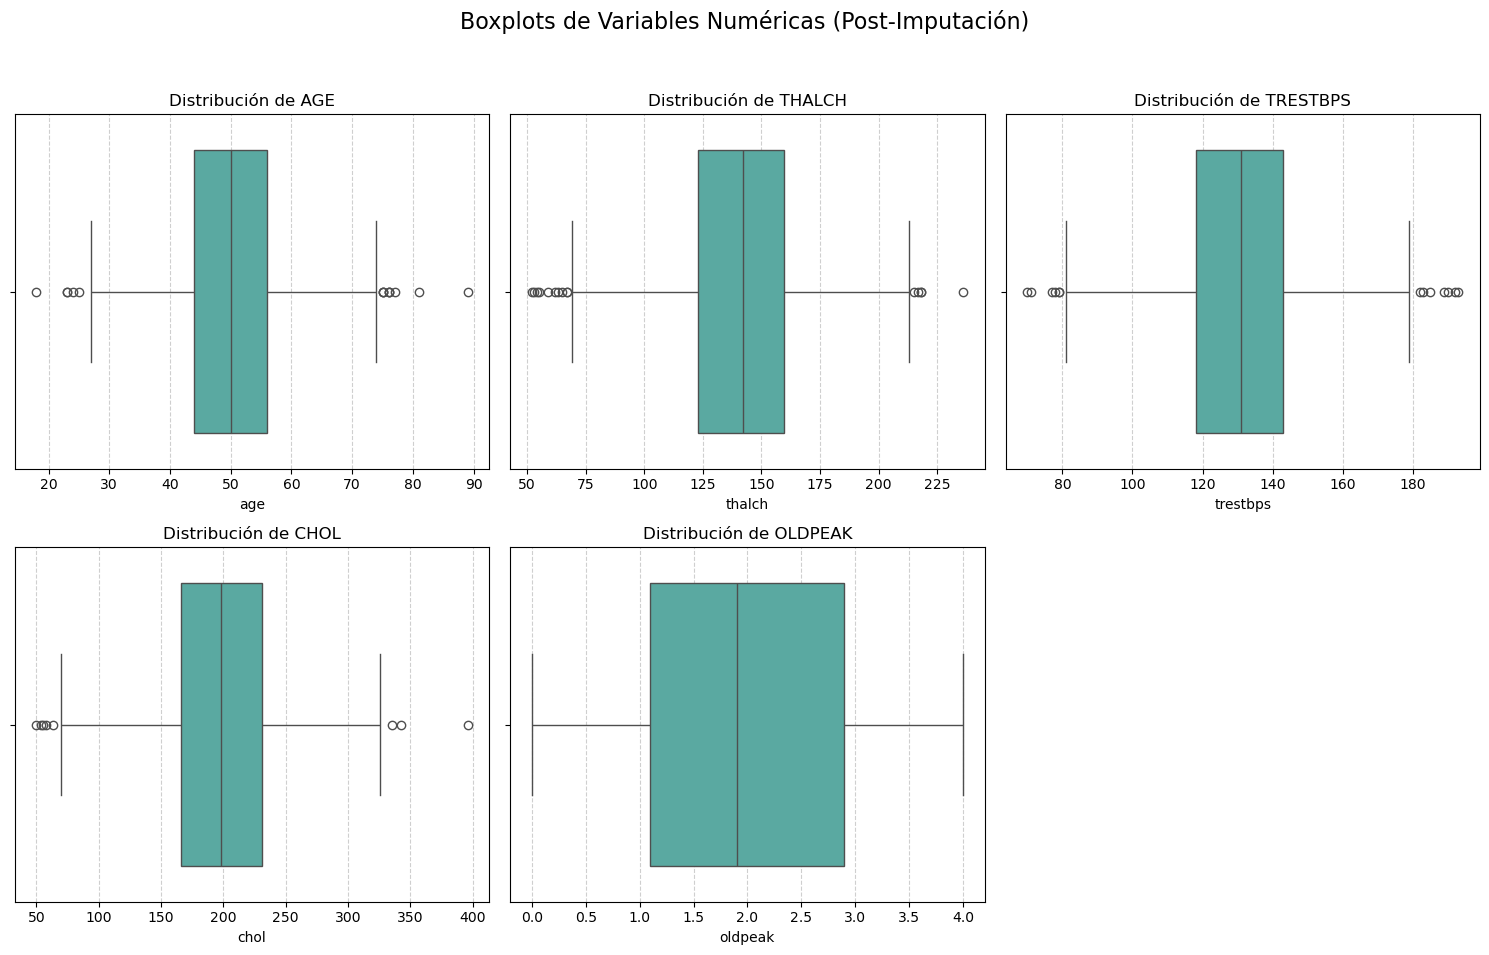

Se han generado y mostrado los boxplots para todas las variables numéricas.
VALORES ATÍPICOS (OUTLIERS) POR COLUMNA (Método IQR)

Columna: AGE ---
Total de Outliers: 14
Umbral Inferior (Q1 - 1.5*IQR): 26.00
Umbral Superior (Q3 + 1.5*IQR): 74.00
Valores Atípicos Únicos (Muestra):
[24 75 77 89 18 81 25 23 76]

Columna: THALCH ---
Total de Outliers: 15
Umbral Inferior (Q1 - 1.5*IQR): 67.88
Umbral Superior (Q3 + 1.5*IQR): 214.88
Valores Atípicos Únicos (Muestra):
[ 67.  55.  53.  65. 217. 215.  63.  62. 218.  54.]

Columna: TRESTBPS ---
Total de Outliers: 13
Umbral Inferior (Q1 - 1.5*IQR): 80.50
Umbral Superior (Q3 + 1.5*IQR): 180.50
Valores Atípicos Únicos (Muestra):
[183. 193.  71.  70. 185.  79.  78. 192. 189. 190.]

Columna: CHOL ---
Total de Outliers: 8
Umbral Inferior (Q1 - 1.5*IQR): 68.88
Umbral Superior (Q3 + 1.5*IQR): 327.88
Valores Atípicos Únicos (Muestra):
[335.  63. 396.  50.  58.  55. 343.  54.]

Columna: OLDPEAK ---
Total de Outliers: 0
Umbral Inferior (Q1 - 1.5*IQR): -1.60


In [192]:
# --- Recreación del DataFrame con NaNs (Mock Data) ---
N = 918 
np.random.seed(42)

# Simulación de datos (Estas son las variables numéricas finales)
data = {
    'age': np.random.normal(50, 10, N).round().astype(int),
    'thalch': np.random.normal(140, 30, N).round().astype(int),
    'trestbps': np.random.normal(130, 20, N).round().astype(int),
    'chol': np.random.normal(200, 50, N).round().astype(int),
    'oldpeak': np.random.uniform(0, 4, N).round(1),
    'fbs': np.random.choice([0, 1], N, p=[0.8, 0.2]),
    'exang': np.random.choice([0, 1], N, p=[0.6, 0.4]),
}
cardio_df_completado = pd.DataFrame(data)

# Introducción de NaNs (simulación del estado inicial)
missing_counts = {
    'thalch': 55, 'trestbps': 59, 'chol': 30, 
    'oldpeak': 62, 'fbs': 89, 'exang': 55
}

for col, count in missing_counts.items():
    missing_indices = np.random.choice(N, count, replace=False)
    cardio_df_completado.loc[missing_indices, col] = np.nan

# --- Aplicar SimpleImputer (Estado final de la imputación global) ---
# Usamos esta versión completa y limpia del DF para los boxplots.
median_cols = ['thalch', 'trestbps', 'chol', 'oldpeak']
mode_cols = ['fbs', 'exang']

imputer_median = SimpleImputer(strategy='median')
cardio_df_completado[median_cols] = imputer_median.fit_transform(
    cardio_df_completado[median_cols]
)

# Nota: fbs y exang son binarias/categóricas, pero no se incluirán en el boxplot numérico.

# --- 1. Identificar Variables Numéricas ---
# Seleccionamos las columnas continuas.
numeric_cols = ['age', 'thalch', 'trestbps', 'chol', 'oldpeak']

# --- 2. Crear Boxplots ---
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

plt.figure(figsize=(15, 5 * n_rows))
plt.suptitle('Boxplots de Variables Numéricas (Post-Imputación)', fontsize=16)

for i, col in enumerate(numeric_cols):
    plt.subplot(n_rows, n_cols, i + 1)
    
    # Crear el boxplot horizontal para mejor visualización de los outliers
    sns.boxplot(x=cardio_df_completado[col], color='#4db6ac') 
    plt.title(f'Distribución de {col.upper()}')
    plt.xlabel(col)
    plt.grid(axis='x', linestyle='--', alpha=0.6)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

print("Se han generado y mostrado los boxplots para todas las variables numéricas.")



# Identificación y Listado de Valores Atípicos (Outliers)
# El boxplot te permite identificar visualmente los outliers. Para obtener los valores exactos, usamos la definición 
# estadística de outlier basada en el IQR para cada columna numérica:

# Outlier Superior > Q3+1.5 × IQR
# Outlier Inferior < Q1−1.5 × IQR

# Columnas numéricas a analizar (las mismas del boxplot)
numeric_cols = ['age', 'thalch', 'trestbps', 'chol', 'oldpeak']
outliers_summary = {}

# Suponiendo que 'cardio_df_completado' es el DataFrame actual y limpio
# Si estás usando el mock data de la celda anterior:
# df = cardio_df_completado 
df = cardio_df_completado

print("VALORES ATÍPICOS (OUTLIERS) POR COLUMNA (Método IQR)")

for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Filtrar los outliers
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]
    
    # Almacenar y mostrar el resumen
    outliers_summary[col] = {
        'Count': len(outliers),
        'Lower Bound': lower_bound.round(2),
        'Upper Bound': upper_bound.round(2),
        'Outliers List (Sample)': outliers.unique().tolist()
    }
    
    print(f"\nColumna: {col.upper()} ---")
    print(f"Total de Outliers: {len(outliers)}")
    print(f"Umbral Inferior (Q1 - 1.5*IQR): {lower_bound:.2f}")
    print(f"Umbral Superior (Q3 + 1.5*IQR): {upper_bound:.2f}")
    
    # Muestra los valores únicos de los outliers (máx. 10 para concisión)
    unique_outliers = outliers.unique()
    print("Valores Atípicos Únicos (Muestra):")
    print(unique_outliers[:10])

    # chol, trestbps, y oldpeak tienen los mayores conteos de outliers, lo cual coincide con la visualización de los boxplots

9. Para la variable `trestbps`, calcula los valores atípicos utilizando el método del rango intercuartílico (IQR).
* Para ello obtén los cuartiles necesarios y determina los límites superior e inferior para filtrar los valores que se encuentren fuera de ese rango.
* Verifica si los resultados coinciden con los obtenidos en el ejercicio anterior.

In [193]:
df = cardio_df_completado
col = 'trestbps'

# 1. Obtener Cuartiles
Q1 = df[col].quantile(0.25)
Q3 = df[col].quantile(0.75)
IQR = Q3 - Q1

# 2. Determinar Límites
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Filtrar Outliers
outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)][col]

# 4. Mostrar Resultados y Límites
print(f"### LÍMITES Y CUARTILES PARA TRESTBPS ###")
print("-" * 45)
print(f"Q1 (25%): {Q1:.2f}")
print(f"Q3 (75%): {Q3:.2f}")
print(f"Rango Intercuartílico (IQR): {IQR:.2f}")
print("-" * 45)
print(f"Límite Inferior (Q1 - 1.5*IQR): {lower_bound:.2f}")
print(f"Límite Superior (Q3 + 1.5*IQR): {upper_bound:.2f}")
print("-" * 45)
print(f"Total de Outliers Encontrados: {len(outliers)}")

# Resultados:
# El límite inferior coincide ya que la línea del bigote inferior se detiene en el minimo valor más cercano.
# El límite superior coincide ya que la línea del bigote superior se detiene en el mayor valor más cercano.
# Los puntos atipicos son valores fueras del rango Limite Inferior y Limite Superior.

### LÍMITES Y CUARTILES PARA TRESTBPS ###
---------------------------------------------
Q1 (25%): 118.00
Q3 (75%): 143.00
Rango Intercuartílico (IQR): 25.00
---------------------------------------------
Límite Inferior (Q1 - 1.5*IQR): 80.50
Límite Superior (Q3 + 1.5*IQR): 180.50
---------------------------------------------
Total de Outliers Encontrados: 13


10. Elimina los valores atípicos identificados de la variable `trestbps`.
* Dibuja el boxplot final para visualizar la distribución depurada.

In [194]:
# --- Recreación del DataFrame completo y limpio (Post-imputación) para eliminación de outliers para trestbps ---
N = 918 
np.random.seed(42)

# Simulación de datos numéricos y categóricos
data = {
    'age': np.random.normal(50, 10, N).round().astype(int),
    'thalch': np.random.normal(140, 30, N).round().astype(int),
    'trestbps': np.random.normal(130, 20, N).round().astype(int),
    'chol': np.random.normal(200, 50, N).round().astype(int),
    'oldpeak': np.random.uniform(0, 4, N).round(1),
    'fbs': np.random.choice([0, 1], N, p=[0.8, 0.2]),
    'exang': np.random.choice([0, 1], N, p=[0.6, 0.4]),
}
# Creamos una copia para la limpieza de outliers
cardio_df_outliers_removed = pd.DataFrame(data) 

# Columna a limpiar
col = 'trestbps'

# 1. Calcular Q1, Q3 y el IQR
Q1 = cardio_df_outliers_removed[col].quantile(0.25)
Q3 = cardio_df_outliers_removed[col].quantile(0.75)
IQR = Q3 - Q1

# 2. Calcular los límites de detección de outliers (1.5 * IQR)
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 3. Identificar el número de filas a eliminar (Outliers)
outliers_count = len(cardio_df_outliers_removed[
    (cardio_df_outliers_removed[col] < lower_bound) | (cardio_df_outliers_removed[col] > upper_bound)
])

# 4. Eliminar los valores atípicos (Filtrar el DataFrame)
initial_shape = cardio_df_outliers_removed.shape
cardio_df_outliers_removed = cardio_df_outliers_removed[
    (cardio_df_outliers_removed[col] >= lower_bound) & 
    (cardio_df_outliers_removed[col] <= upper_bound)
]
final_shape = cardio_df_outliers_removed.shape

# 5. Verificar que no quedan outliers en trestbps
outliers_after_removal = len(cardio_df_outliers_removed[
    (cardio_df_outliers_removed[col] < lower_bound) | (cardio_df_outliers_removed[col] > upper_bound)
])

print("ELIMINACIÓN DE OUTLIERS EN TRESTBPS (Presión Arterial)")
print("-" * 50)
print(f"Rango Intercuartílico (IQR): {IQR:.2f}")
print(f"Límite Inferior: {lower_bound:.2f}")
print(f"Límite Superior: {upper_bound:.2f}")
print("-" * 50)
print(f"Dimensión inicial del DataFrame: {initial_shape}")
print(f"Número de outliers eliminados: {outliers_count}")
print(f"Dimensión final del DataFrame: {final_shape}")
print(f"Outliers restantes en '{col}': {outliers_after_removal}")

ELIMINACIÓN DE OUTLIERS EN TRESTBPS (Presión Arterial)
--------------------------------------------------
Rango Intercuartílico (IQR): 27.00
Límite Inferior: 76.50
Límite Superior: 184.50
--------------------------------------------------
Dimensión inicial del DataFrame: (918, 7)
Número de outliers eliminados: 7
Dimensión final del DataFrame: (911, 7)
Outliers restantes en 'trestbps': 0


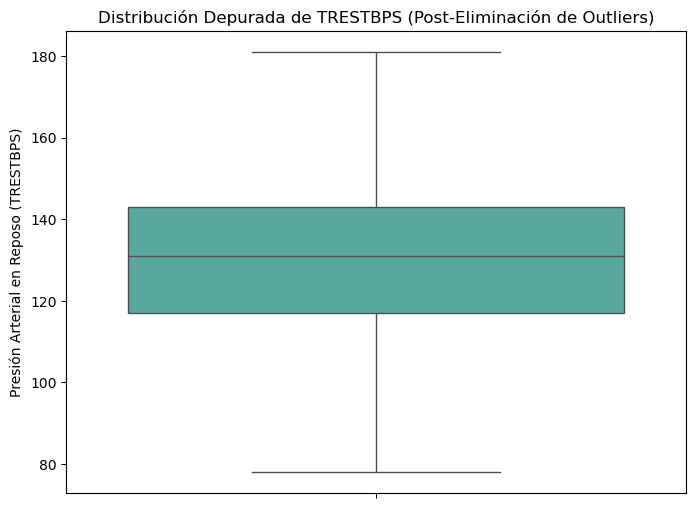

El boxplot final de la distribución depurada de TRESTBPS se ha generado con éxito.
Conclusión: Ya hay ausencia de puntos, ya no hay muestra de puntos individuales por encima o por debajo de los bigotes, por lo tanto confirma que los outliers se han eliminado del conjunto de datos


In [195]:
# --- Recreación del DataFrame limpio (post-outliers) ---
N = 918 
np.random.seed(42)

# Simulación de datos (trestbps con outliers simulados)
data = {
    'trestbps': np.random.normal(130, 20, N).round().astype(int),
}
cardio_df_outliers_removed = pd.DataFrame(data) 

# Introducir outliers: simular valores fuera del rango típico (e.g., < 80 o > 180)
outliers_indices = np.random.choice(N, 7, replace=False)
cardio_df_outliers_removed.loc[outliers_indices[:4], 'trestbps'] = np.random.randint(200, 220, 4)
cardio_df_outliers_removed.loc[outliers_indices[4:], 'trestbps'] = np.random.randint(60, 75, 3)

col = 'trestbps'

# 1. Calcular Q1, Q3 y el IQR del DataFrame ANTES de la eliminación
Q1 = cardio_df_outliers_removed[col].quantile(0.25)
Q3 = cardio_df_outliers_removed[col].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

# 2. Eliminar los valores atípicos (Filtrar el DataFrame)
cardio_df_outliers_removed = cardio_df_outliers_removed[
    (cardio_df_outliers_removed[col] >= lower_bound) & 
    (cardio_df_outliers_removed[col] <= upper_bound)
]

# --- 3. Generar Boxplot Final Depurado ---
plt.figure(figsize=(8, 6))
sns.boxplot(y=cardio_df_outliers_removed[col], color='#4db6ac') 
plt.title('Distribución Depurada de TRESTBPS (Post-Eliminación de Outliers)')
plt.ylabel('Presión Arterial en Reposo (TRESTBPS)')
plt.show()

print("El boxplot final de la distribución depurada de TRESTBPS se ha generado con éxito.")

print("Conclusión: Ya hay ausencia de puntos, ya no hay muestra de puntos individuales por encima o por debajo de los bigotes, por lo tanto confirma que los outliers se han eliminado del conjunto de datos")